# 1) Demonstrate Bayesian Strategy Analysis

This notebook shows a single-strategy Bayesian analysis step by step.

Use this workflow for your own dataset:
1. Import packages and toolbox functions
2. Load your CSV
3. Standardize column/value format
4. Validate required columns
5. Run Bayesian update across trials


You do not need to edit notebook code; set your `.csv` path in `config.py` (`data_path`) and run the cells.



In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import strategymodels

from config import data_path, strategy_name, prior_type, decay_rate, save_output_csv
from Functions.standardize_dataset import standardize_dataset
from Functions.set_Beta_prior import set_priors
from Functions.update_strategy_posterior_probability import update_strategy_posterior_probability
from Functions.Summaries_of_Beta_distribution import summaries_of_Beta_Distribution
from Functions.plotSessionStructure import plotSessionStructure

## Step 1: Load and standardize your dataset

`data_path` comes from `config.py`. To analyse your own file, update only `data_path` in `config.py`.

This step:
- Loads your CSV into `TestData`
- Standardizes the key columns (`TrialIndex`, `Choice`, `CuePosition`, `Reward`)
- Checks that `TrialIndex` exists
- Shows the first rows so you can verify formatting


In [2]:
TestData = pd.read_csv(data_path)
TestData = standardize_dataset(TestData)

if "TrialIndex" not in TestData.columns:
    raise ValueError("Dataset must contain a 'TrialIndex' column.")

TestData.head()

,TrialIndex,SessionIndex,TargetRule,Choice,CuePosition,Reward,RuleChangeTrials,NewSessionTrials
0,1,15,go right,left,right,no,0,0
1,2,15,go right,left,right,no,0,0
2,3,15,go right,right,right,yes,0,0
3,4,15,go right,left,right,no,0,0
4,5,15,go right,left,right,no,0,0


In [3]:
available_strategies = [
    s for s in dir(strategymodels)
    if callable(getattr(strategymodels, s)) and not s.startswith("_")
]

try:
    strategy_fcn = getattr(strategymodels, strategy_name)
except AttributeError:
    raise ValueError(
        f"Strategy '{strategy_name}' not found.\nAvailable strategies:\n{available_strategies}"
    )

## Step 3: Initialize priors and output storage

In [4]:
alpha0, beta0 = set_priors(prior_type)
no_Trials = len(TestData)

success_total = 0
failure_total = 0

Output = pd.DataFrame(columns=["Alpha", "Beta", "MAPprobability", "Precision"])

## Step 4: Run Bayesian updates trial by trial

In [5]:
for trial in range(len(TestData)):
    rows_of_data = TestData.iloc[0:trial+1]

    trial_type = strategy_fcn(rows_of_data)

    success_total, failure_total, Alpha, Beta = update_strategy_posterior_probability(
        trial_type,
        decay_rate,
        success_total,
        failure_total,
        alpha0,
        beta0,
    )

    MAPprobability = summaries_of_Beta_Distribution(Alpha, Beta, "MAP")
    precision = summaries_of_Beta_Distribution(Alpha, Beta, "precision")

    new_row = {
        "Alpha": Alpha,
        "Beta": Beta,
        "MAPprobability": MAPprobability,
        "Precision": precision,
    }

    Output = pd.concat([Output, pd.DataFrame([new_row])], ignore_index=True)

if save_output_csv:
    Output.to_csv("Output.csv", index=False)

/var/folders/1p/18jwl7x13xdgtw3zwr3q9zfr0000gn/T/ipykernel_94444/1390317834.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Output = pd.concat([Output, pd.DataFrame([new_row])], ignore_index=True)


## Step 5: Plot MAP probability across trials

/Users/cerenkimyonok/Desktop/deneme/Functions/plotSessionStructure.py:32: UserWarning: Legend does not support handles for Text instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()  # add legend
/var/folders/1p/18jwl7x13xdgtw3zwr3q9zfr0000gn/T/ipykernel_94444/549809723.py:22: UserWarning: Legend does not support handles for Text instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


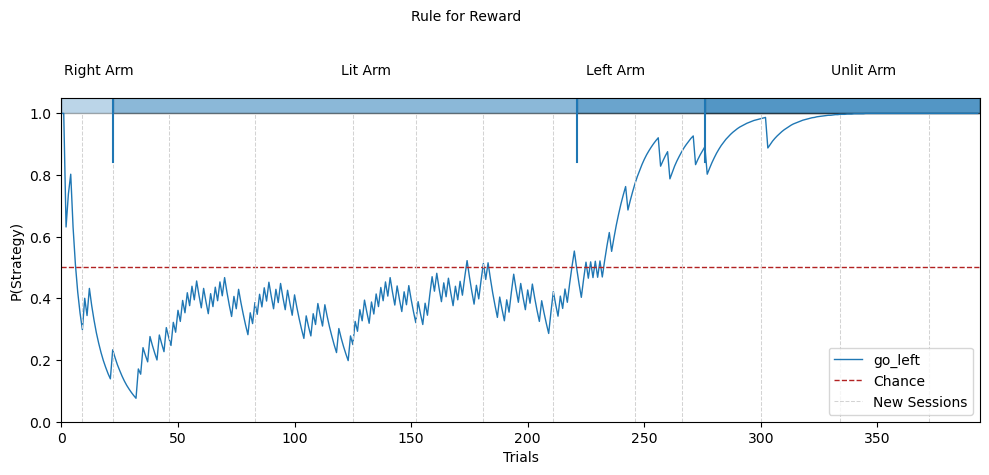

In [6]:
plt.figure(figsize=(10, 5))

plt.plot(Output["MAPprobability"], linewidth=1.0, label=strategy_name)

plt.xlabel("Trials")
plt.ylabel("P(Strategy)")

plt.axhline(
    y=0.5,
    color="firebrick",
    linestyle="--",
    linewidth=1.0,
    label="Chance",
)

try:
    plotSessionStructure(TestData)
except Exception:
    pass

plt.axis([0, no_Trials, 0, 1.05])
plt.legend()
plt.tight_layout()
plt.show()

---
## Next Step

To analyse multiple strategies and reproduce Figure 1, run:

**2_Replicate_Figure1.ipynb**
